Import library

In [2]:
import pandas as pd
import re
from datetime import datetime
import yaml

In [3]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

Load Log File

In [4]:
import os

raw_dir = config["data"]["raw_dir"]

log_file = os.path.join("..", raw_dir, "access.log.12")

with open(log_file, "r") as f:
    logs = f.readlines()

len(logs)

11615

In [5]:
log_pattern = re.compile(
    r'(?P<ip>\S+) - - \[(?P<time>.*?)\] '
    r'"(?P<method>\S+) (?P<endpoint>\S+) (?P<protocol>.*?)" '
    r'(?P<status>\d+) (?P<size>\d+) '
    r'"(?P<referer>.*?)" "(?P<user_agent>.*?)" '
    r'X-Forwarded-For="(?P<real_ip>.*?)"'
)

In [6]:
records = []

for log in logs:
    match = log_pattern.search(log)
    if match:
        records.append(match.groupdict())

df = pd.DataFrame(records)
df.head()

,ip,time,method,endpoint,protocol,status,size,referer,user_agent,real_ip
0,127.0.0.1,05/May/2025:09:08:24 +0000,OPTIONS,/api/v1/auths/login,HTTP/1.1,204,0,https://filkompedia.yogarn.my.id/,Mozilla/5.0 (X11; Linux x86_64; rv:138.0) Geck...,175.45.191.10
1,127.0.0.1,05/May/2025:09:08:25 +0000,POST,/api/v1/auths/login,HTTP/1.1,401,62,https://filkompedia.yogarn.my.id/,Mozilla/5.0 (X11; Linux x86_64; rv:138.0) Geck...,175.45.191.10
2,127.0.0.1,05/May/2025:09:09:36 +0000,OPTIONS,/api/v1/auths/login,HTTP/1.1,204,0,https://filkompedia.yogarn.my.id/,Mozilla/5.0 (X11; Linux x86_64; rv:138.0) Geck...,175.45.191.15
3,127.0.0.1,05/May/2025:09:09:37 +0000,POST,/api/v1/auths/login,HTTP/1.1,200,33,https://filkompedia.yogarn.my.id/,Mozilla/5.0 (X11; Linux x86_64; rv:138.0) Geck...,175.45.191.10
4,127.0.0.1,05/May/2025:09:09:37 +0000,GET,/api/v1/books?search=&page=1&size=9,HTTP/1.1,200,8846,https://filkompedia.yogarn.my.id/,Mozilla/5.0 (X11; Linux x86_64; rv:138.0) Geck...,175.45.191.10


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11614 entries, 0 to 11613
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   ip          11614 non-null  str                
 1   time        11614 non-null  datetime64[us, UTC]
 2   method      11614 non-null  str                
 3   endpoint    11614 non-null  str                
 4   protocol    11614 non-null  str                
 5   status      11614 non-null  str                
 6   size        11614 non-null  str                
 7   referer     11614 non-null  str                
 8   user_agent  11614 non-null  str                
 9   real_ip     11614 non-null  str                
dtypes: datetime64[us, UTC](1), str(9)
memory usage: 907.5 KB


In [26]:
df["size"] = pd.to_numeric(df["size"], errors="coerce")

## Explore

In [7]:
df["method"].value_counts()

method
POST       9434
GET        2113
OPTIONS      57
PATCH         6
HEAD          2
DELETE        1
TRACK         1
Name: count, dtype: int64

In [8]:
df["status"].value_counts()

status
200    5298
401    5061
304    1026
400     133
204      57
403      27
404       5
201       4
405       2
409       1
Name: count, dtype: int64

In [9]:
df["endpoint"].value_counts().head(10)

endpoint
/api/v1/auths/login                        9448
/api/v1/books?search=&page=1&size=9          65
/?token=Kp5rLtCf5Hrs                         36
/@vite/client                                34
/src/main.tsx                                34
/@react-refresh                              34
/src/App.tsx                                 34
/node_modules/vite/dist/client/env.mjs       34
/src/pages/admin/index.tsx                   34
/src/pages/admin/books/create/index.tsx      34
Name: count, dtype: int64

In [10]:
df["real_ip"].value_counts().head(10)

real_ip
175.45.188.252     9928
175.45.191.19       533
175.45.191.10       297
175.45.191.11       231
172.236.213.119     198
175.45.191.12        91
175.45.191.15        75
175.45.191.8         61
175.45.191.9         52
175.45.191.13        46
Name: count, dtype: int64

<Axes: xlabel='time'>

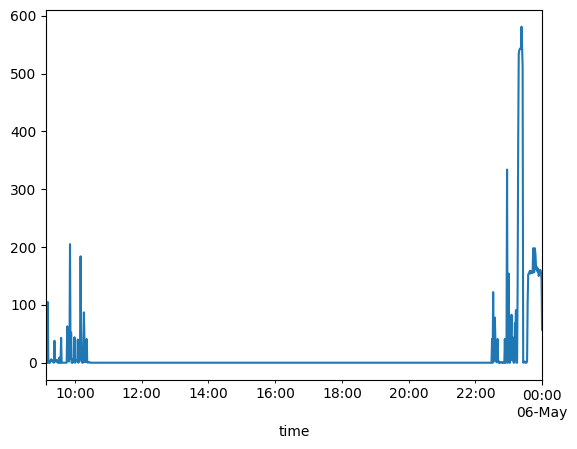

In [13]:
df["time"] = pd.to_datetime(df["time"], format="%d/%b/%Y:%H:%M:%S %z")

# resample per menit
df.set_index("time").resample("1min").size().plot()

<Axes: xlabel='time'>

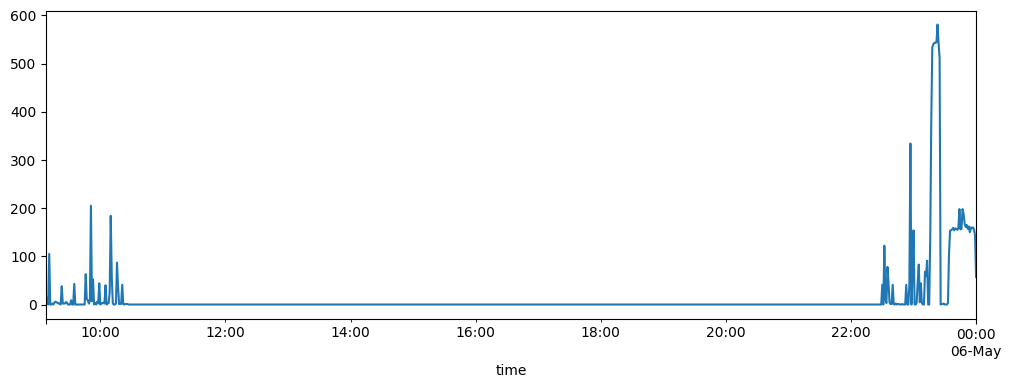

In [14]:
req_per_min = df.set_index("time").resample("1min").size()

rolling_mean = req_per_min.rolling(10).mean()
rolling_std = req_per_min.rolling(10).std()

zscore = (req_per_min - rolling_mean) / rolling_std

anomaly = zscore[zscore > 3]

req_per_min.plot(figsize=(12,4))

In [15]:
ip_rate = (
    df.set_index("time")
      .groupby("ip")
      .resample("1min")
      .size()
      .reset_index(name="count")
)

ip_rate.sort_values("count", ascending=False).head()

,ip,time,count
855,127.0.0.1,2025-05-05 23:23:00+00:00,581
854,127.0.0.1,2025-05-05 23:22:00+00:00,544
853,127.0.0.1,2025-05-05 23:21:00+00:00,543
852,127.0.0.1,2025-05-05 23:20:00+00:00,543
856,127.0.0.1,2025-05-05 23:24:00+00:00,543


In [16]:
pivot = pd.crosstab(df["endpoint"], df["status"])

pivot.head()

status,200,201,204,304,400,401,403,404,405,409
endpoint,,,,,,,,,,
/,3,0,0,0,0,0,0,0,0,0
/.well-known/security.txt,1,0,0,0,0,0,0,0,0,0
/?token=Kp5rLtCf5Hrs,36,0,0,0,0,0,0,0,0,0
/@react-refresh,6,0,0,28,0,0,0,0,0,0
/@vite/client,5,0,0,29,0,0,0,0,0,0


<Axes: xlabel='status', ylabel='endpoint'>

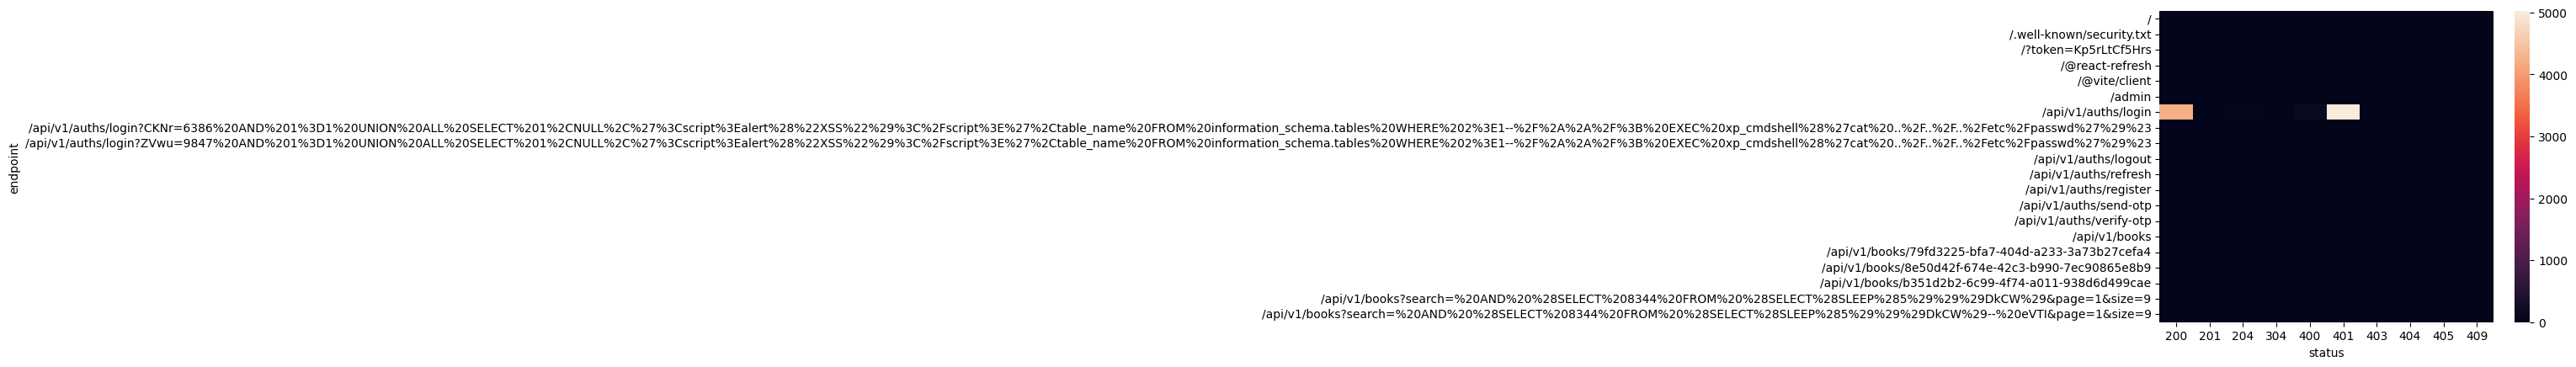

In [19]:
import seaborn as sns
sns.heatmap(pivot.head(20))

<Axes: ylabel='Frequency'>

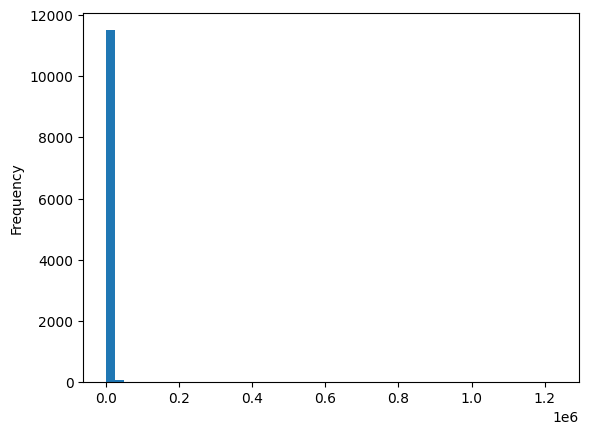

In [27]:
df["size"].describe()
df["size"].plot(kind="hist", bins=50)